# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [1]:
# Install missing packages in Colab if needed
!pip -q install lifelines statsmodels

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from lifelines import CoxPHFitter, KaplanMeierFitter
from csv import DictReader
from io import StringIO
from urllib.request import urlopen

BASE_URL = "https://raw.githubusercontent.com/propublica/compas-analysis/master/"
URLS = {
    "two_year": BASE_URL + "compas-scores-two-years.csv",
    "violent_two_year": BASE_URL + "compas-scores-two-years-violent.csv",
    "cox": BASE_URL + "cox-parsed.csv",
    "violent_cox": BASE_URL + "cox-violent-parsed.csv",
}

def load_csv(url):
    return pd.read_csv(url)

def logistic(x):
    return np.exp(x) / (1 + np.exp(x))

def rr_from_coef(coef, control):
    return np.exp(coef) / (1 - control + (control * np.exp(coef)))

def count_series(series):
    return series.value_counts(dropna=False).sort_index()

def plot_decile_histograms(df, score_col, left_title, right_title, ymax=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, race, title in zip(
        axes,
        ["African-American", "Caucasian"],
        [left_title, right_title]
    ):
        subset = df[df["race"] == race]
        counts = subset[score_col].value_counts().sort_index()
        counts.plot(kind="bar", ax=ax)
        ax.set_xlabel(score_col.replace("_", " ").title())
        ax.set_ylabel("Count")
        ax.set_title(title)
        if ymax is not None:
            ax.set_ylim(0, ymax)
    plt.tight_layout()
    plt.show()

def km_summary_at_time(df, group_col="score_text", time=730):
    rows = []
    for group_name, group_df in df.groupby(group_col):
        kmf = KaplanMeierFitter()
        kmf.fit(
            durations=group_df["end"],
            event_observed=group_df["event"],
            entry=group_df["start"],
            label=str(group_name),
        )
        rows.append(
            {
                "group": group_name,
                "n": len(group_df),
                f"survival_at_{time}": float(kmf.survival_function_at_times(time).iloc[0]),
            }
        )
    return pd.DataFrame(rows).sort_values("group").reset_index(drop=True)

def plot_km_by_score(df, title):
    fig, ax = plt.subplots(figsize=(8, 5))
    for score_name, group_df in df.groupby("score_text"):
        kmf = KaplanMeierFitter()
        kmf.fit(
            durations=group_df["end"],
            event_observed=group_df["event"],
            entry=group_df["start"],
            label=str(score_name),
        )
        kmf.plot_survival_function(ax=ax, ci_show=True)
    ax.set_title(title)
    ax.set_xlabel("Days")
    ax.set_ylabel("Survival probability")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

def make_design_matrix(df, categorical_refs=None, numeric_cols=None, interactions=None):
    categorical_refs = categorical_refs or {}
    numeric_cols = numeric_cols or []
    interactions = interactions or []

    X = pd.DataFrame(index=df.index)

    for col in numeric_cols:
        X[col] = df[col].astype(float)

    for col, ref in categorical_refs.items():
        dummies = pd.get_dummies(df[col], prefix=col, dtype=float)
        ref_col = f"{col}_{ref}"
        if ref_col in dummies.columns:
            dummies = dummies.drop(columns=[ref_col])
        X = pd.concat([X, dummies], axis=1)

    for left_prefix, right_prefix in interactions:
        left_cols = [c for c in X.columns if c.startswith(f"{left_prefix}_")]
        right_cols = [c for c in X.columns if c.startswith(f"{right_prefix}_")]
        for lc in left_cols:
            for rc in right_cols:
                X[f"{lc}__x__{rc}"] = X[lc] * X[rc]

    return X

def fit_cox_model(df, categorical_refs=None, numeric_cols=None, interactions=None):
    X = make_design_matrix(
        df,
        categorical_refs=categorical_refs,
        numeric_cols=numeric_cols,
        interactions=interactions,
    )
    fit_df = pd.concat([df[["start", "end", "event"]].reset_index(drop=True), X.reset_index(drop=True)], axis=1).dropna()
    cph = CoxPHFitter()
    cph.fit(fit_df, duration_col="end", event_col="event", entry_col="start")
    return cph, fit_df

# Utilities adapted from truth_tables.py so the notebook is self-contained
class PeekyReader:
    def __init__(self, reader):
        self.peeked = None
        self.reader = reader

    def peek(self):
        if self.peeked is None:
            self.peeked = next(self.reader)
        return self.peeked

    def __iter__(self):
        return self

    def __next__(self):
        if self.peeked is not None:
            ret = self.peeked
            self.peeked = None
            return ret
        try:
            return next(self.reader)
        except StopIteration:
            self.peeked = None
            raise StopIteration

class Person:
    def __init__(self, reader):
        self.__rows = []
        self.__idx = reader.peek()["id"]
        try:
            while reader.peek()["id"] == self.__idx:
                self.__rows.append(next(reader))
        except StopIteration:
            pass

    @property
    def lifetime(self):
        memo = 0
        for it in self.__rows:
            memo += int(it["end"]) - int(it["start"])
        return memo

    @property
    def recidivist(self):
        return (self.__rows[0]["is_recid"] == "1" and self.lifetime <= 730)

    @property
    def violent_recidivist(self):
        return (self.__rows[0]["is_violent_recid"] == "1" and self.lifetime <= 730)

    @property
    def low(self):
        return self.__rows[0]["score_text"] == "Low"

    @property
    def high(self):
        return not self.low

    @property
    def low_med(self):
        return self.low or self.score == "Medium"

    @property
    def true_high(self):
        return self.score == "High"

    @property
    def vlow(self):
        return self.__rows[0]["v_score_text"] == "Low"

    @property
    def vhigh(self):
        return not self.vlow

    @property
    def vlow_med(self):
        return self.vlow or self.vscore == "Medium"

    @property
    def vtrue_high(self):
        return self.vscore == "High"

    @property
    def score(self):
        return self.__rows[0]["score_text"]

    @property
    def vscore(self):
        return self.__rows[0]["v_score_text"]

    @property
    def race(self):
        return self.__rows[0]["race"]

    @property
    def valid(self):
        return (
            self.__rows[0]["is_recid"] != "-1"
            and ((self.recidivist and self.lifetime <= 730) or self.lifetime > 730)
        )

    @property
    def compas_felony(self):
        return "F" in self.__rows[0]["c_charge_degree"]

    @property
    def score_valid(self):
        return self.score in ["Low", "Medium", "High"]

    @property
    def vscore_valid(self):
        return self.vscore in ["Low", "Medium", "High"]

    @property
    def rows(self):
        return self.__rows

def count(fn, data):
    return len(list(filter(fn, list(data))))

def print_truth_table(tn, fp, fn, tp):
    surv_n = tn + fp
    recid_n = tp + fn
    print(" \tLow\tHigh")
    print(f"Survived \t{tn}\t{fp}\t{surv_n / (surv_n + recid_n):.2f}")
    print(f"Recidivated\t{fn}\t{tp}\t{recid_n / (surv_n + recid_n):.2f}")
    print(f"Total: {surv_n + recid_n:.2f}")
    print(f"False positive rate: {fp / surv_n * 100:.2f}")
    print(f"False negative rate: {fn / recid_n * 100:.2f}")
    spec = tn / (tn + fp)
    sens = tp / (tp + fn)
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)
    prev = recid_n / (surv_n + recid_n)
    print(f"Specificity: {spec:.2f}")
    print(f"Sensitivity: {sens:.2f}")
    print(f"Prevalence: {prev:.2f}")
    print(f"PPV: {ppv:.2f}")
    print(f"NPV: {npv:.2f}")
    print(f"LR+: {sens / (1 - spec):.2f}")
    print(f"LR-: {(1 - sens) / spec:.2f}")

def table(recid, surv, prefix=""):
    tn = count(lambda i: getattr(i, prefix + "low"), surv)
    fp = count(lambda i: getattr(i, prefix + "high"), surv)
    fn = count(lambda i: getattr(i, prefix + "low"), recid)
    tp = count(lambda i: getattr(i, prefix + "high"), recid)
    print_truth_table(tn, fp, fn, tp)

def hightable(recid, surv, prefix=""):
    tn = count(lambda i: getattr(i, prefix + "low_med"), surv)
    fp = count(lambda i: getattr(i, prefix + "true_high"), surv)
    fn = count(lambda i: getattr(i, prefix + "low_med"), recid)
    tp = count(lambda i: getattr(i, prefix + "true_high"), recid)
    print_truth_table(tn, fp, fn, tp)

def vtable(recid, surv):
    table(recid, surv, prefix="v")

def vhightable(recid, surv):
    hightable(recid, surv, prefix="v")

def is_race(race):
    return lambda x: x.race == race

def remote_reader(url):
    text = urlopen(url).read().decode("utf-8")
    return PeekyReader(DictReader(StringIO(text)))

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.9 MB/s eta 0:00:00


In [2]:
raw_data = load_csv(URLS["two_year"])
len(raw_data)

7214

However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [3]:
df = raw_data[
    [
        "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
        "priors_count", "days_b_screening_arrest", "decile_score",
        "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
    ]
].copy()

df = df[
    (df["days_b_screening_arrest"] <= 30)
    & (df["days_b_screening_arrest"] >= -30)
    & (df["is_recid"] != -1)
    & (df["c_charge_degree"] != "O")
    & (df["score_text"] != "N/A")
].copy()

len(df)

6172

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [4]:
df["length_of_stay"] = (
    pd.to_datetime(df["c_jail_out"]) - pd.to_datetime(df["c_jail_in"])
).dt.days

df["length_of_stay"].corr(df["decile_score"])

np.float64(0.20747808478031807)

After filtering we have the following demographic breakdown:

In [5]:
count_series(df["age_cat"])

,count
age_cat,
25 - 45,3532
Greater than 45,1293
Less than 25,1347


In [6]:
count_series(df["race"])

,count
race,
African-American,3175
Asian,31
Caucasian,2103
Hispanic,509
Native American,11
Other,343


In [7]:
print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [8]:
count_series(df["score_text"])

,count
score_text,
High,1144
Low,3421
Medium,1607


In [9]:
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [10]:
count_series(df["sex"])

,count
sex,
Female,1175
Male,4997


In [11]:
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [12]:
int((df["two_year_recid"] == 1).sum())

2809

In [13]:
(df["two_year_recid"] == 1).mean() * 100

np.float64(45.51198963058976)

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

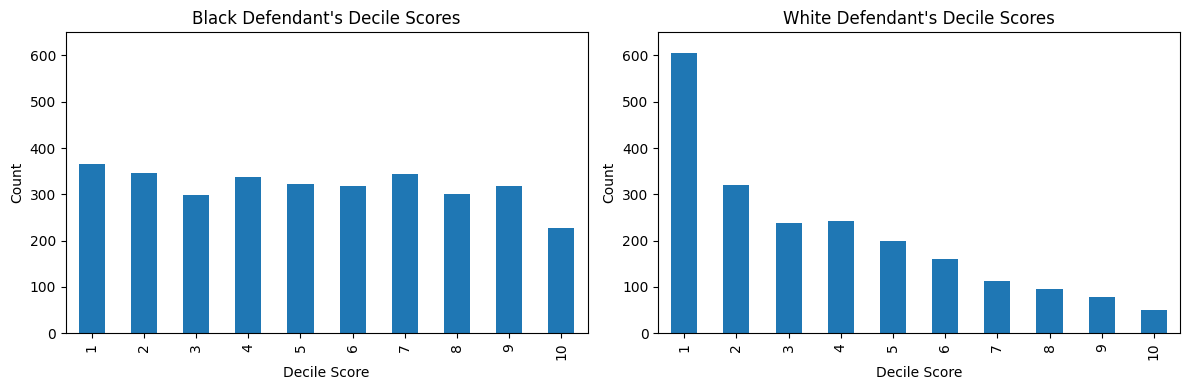

In [14]:
plot_decile_histograms(
    df,
    score_col="decile_score",
    left_title="Black Defendant's Decile Scores",
    right_title="White Defendant's Decile Scores",
    ymax=650,
)

In [15]:
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [16]:
df = df.copy()
df["score_binary"] = (df["score_text"] != "Low").astype(int)

model = smf.logit(
    "score_binary ~ C(sex, Treatment(reference='Male')) + "
    "C(age_cat, Treatment(reference='25 - 45')) + "
    "C(race, Treatment(reference='Caucasian')) + "
    "priors_count + C(c_charge_degree, Treatment(reference='M')) + two_year_recid",
    data=df,
).fit(disp=False)

print(model.summary())

                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        23:19:53   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------
Intercept                                                        -1.8368      0.084    -21.986      0.000   

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [17]:
control = logistic(model.params["Intercept"])
coef_black = model.params["C(race, Treatment(reference='Caucasian'))[T.African-American]"]
rr_from_coef(coef_black, control)

np.float64(1.4866178138286874)

Women are 19.4% more likely than men to get a higher score.

In [18]:
coef_female = model.params["C(sex, Treatment(reference='Male'))[T.Female]"]
rr_from_coef(coef_female, control)

np.float64(1.2065886074591075)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [19]:
coef_young = model.params["C(age_cat, Treatment(reference='25 - 45'))[T.Less than 25]"]
rr_from_coef(coef_young, control)

np.float64(2.698723446405118)

### Risk of Violent Recidivism

Compas also offers a score that aims to measure a persons risk of violent recidivism, which has a similar overall accuracy to the Recidivism score. As before, we can use a logistic regression to test for racial bias.

In [20]:
raw_data = load_csv(URLS["violent_two_year"])
len(raw_data)

4743

In [21]:
df = raw_data[
    [
        "age", "c_charge_degree", "race", "age_cat", "v_score_text", "sex",
        "priors_count", "days_b_screening_arrest", "v_decile_score",
        "is_recid", "two_year_recid"
    ]
].copy()

df = df[
    (df["days_b_screening_arrest"] <= 30)
    & (df["days_b_screening_arrest"] >= -30)
    & (df["is_recid"] != -1)
    & (df["c_charge_degree"] != "O")
    & (df["v_score_text"] != "N/A")
].copy()

len(df)

4020

In [22]:
count_series(df["age_cat"])

,count
age_cat,
25 - 45,2300
Greater than 45,954
Less than 25,766


In [23]:
count_series(df["race"])

,count
race,
African-American,1918
Asian,26
Caucasian,1459
Hispanic,355
Native American,7
Other,255


In [24]:
count_series(df["v_score_text"])

,count
v_score_text,
High,279
Low,2913
Medium,828


In [25]:
(df["two_year_recid"] == 1).mean() * 100

np.float64(16.218905472636816)

In [26]:
int((df["two_year_recid"] == 1).sum())

652

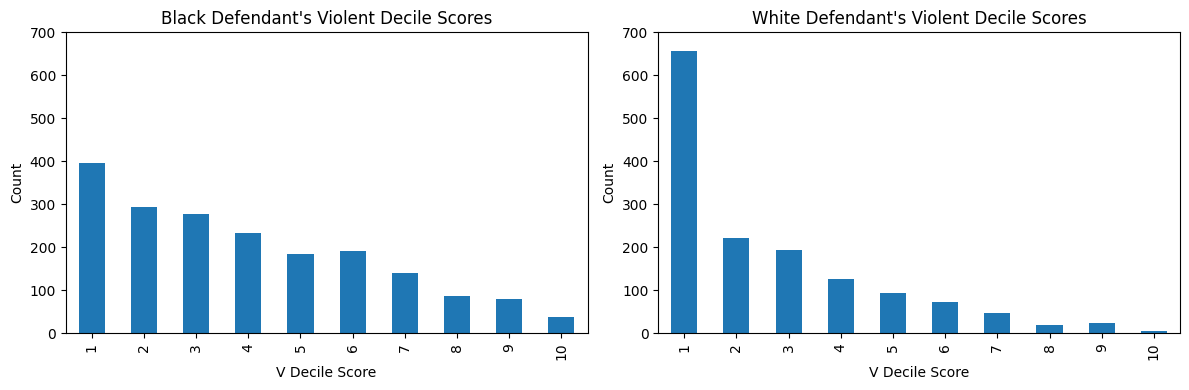

In [27]:
plot_decile_histograms(
    df,
    score_col="v_decile_score",
    left_title="Black Defendant's Violent Decile Scores",
    right_title="White Defendant's Violent Decile Scores",
    ymax=700,
)

In [28]:
df = df.copy()
df["score_binary"] = (df["v_score_text"] != "Low").astype(int)

model = smf.logit(
    "score_binary ~ C(sex, Treatment(reference='Male')) + "
    "C(age_cat, Treatment(reference='25 - 45')) + "
    "C(race, Treatment(reference='Caucasian')) + "
    "priors_count + C(c_charge_degree, Treatment(reference='M')) + two_year_recid",
    data=df,
).fit(disp=False)

print(model.summary())

                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 4020
Model:                          Logit   Df Residuals:                     4008
Method:                           MLE   Df Model:                           11
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.3662
Time:                        23:19:53   Log-Likelihood:                -1499.4
converged:                       True   LL-Null:                       -2365.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------
Intercept                                                        -2.4064      0.121    -19.837      0.000   

The violent score overpredicts recidivism for black defendants by 77.3% compared to white defendants.

In [29]:
control = logistic(model.params["Intercept"])
coef_black = model.params["C(race, Treatment(reference='Caucasian'))[T.African-American]"]
rr_from_coef(coef_black, control)

np.float64(1.7943458411437376)

Defendands under 25 are 7.4 times as likely to get a higher score as middle aged defendants.

In [30]:
coef_young = model.params["C(age_cat, Treatment(reference='25 - 45'))[T.Less than 25]"]
rr_from_coef(coef_young, control)

np.float64(8.186285599374763)

## Predictive Accuracy of COMPAS

In order to test whether Compas scores do an accurate job of deciding whether an offender is Low, Medium or High risk,  we ran a Cox Proportional Hazards model. Northpointe, the company that created COMPAS and markets it to Law Enforcement, also ran a Cox model in their [validation study](http://cjb.sagepub.com/content/36/1/21.abstract).

We used the counting model and removed people when they were incarcerated. Due to errors in the underlying jail data, we need to filter out 32 rows that have an end date more than the start date. Considering that there are 13,334 total rows in the data, such a small amount of errors will not affect the results.

In [31]:
data = load_csv(URLS["cox"])
data = data[(data["score_text"] != "N/A") & (data["end"] > data["start"])].copy()

race_order = ["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"]
score_order = ["Low", "Medium", "High"]

data["race_factor"] = pd.Categorical(data["race"], categories=race_order)
data["score_factor"] = pd.Categorical(data["score_text"], categories=score_order)

grp = data.drop_duplicates("id").copy()
len(grp)

10325

In [32]:
count_series(grp["score_factor"])

,count
score_factor,
Low,5751
Medium,2611
High,1952
NaN,11


In [33]:
count_series(grp["race_factor"])

,count
race_factor,
Caucasian,3576
African-American,5150
Asian,51
Hispanic,944
Native American,32
Other,572


In [34]:
cph_score, score_fit_df = fit_cox_model(
    data,
    categorical_refs={"score_factor": "Low"},
)
cph_score.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
score_factor_Medium,0.796990,2.218853,0.040758,0.717107,0.876874,2.048498,2.403375,0.0,19.554348,3.788139e-85,280.442399
score_factor_High,1.250383,3.491681,0.041444,1.169154,1.331612,3.219269,3.787144,0.0,30.170365,5.799725e-200,661.849634


People placed in the High category are 3.5 times as likely to recidivate, and the COMPAS system's concordance 63.6%. This is lower than the accuracy quoted in the Northpoint study of 68%.

In [35]:
cph_decile, decile_fit_df = fit_cox_model(
    data,
    numeric_cols=["decile_score"],
)
cph_decile.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
decile_score,0.194837,1.215113,0.005793,0.183482,0.206192,1.201393,1.228989,0.0,33.630321,6.048095e-248,821.241687


COMPAS's decile scores are a bit more accurate at 66%.

We can test if the algorithm is behaving differently across races by including a race interaction term in the cox model.

In [36]:
cph_interaction, interaction_fit_df = fit_cox_model(
    data,
    categorical_refs={"race_factor": "Caucasian", "score_factor": "Low"},
    interactions=[("race_factor", "score_factor")],
)
cph_interaction.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
race_factor_African-American,0.280656,1.323998,0.060740,0.161608,0.399704,1.175399,1.491384,0.0,4.620616,3.826030e-06,17.995720
race_factor_Asian,-0.775350,0.460542,0.501998,-1.759248,0.208548,0.172174,1.231888,0.0,-1.544529,1.224603e-01,3.029614
race_factor_Hispanic,-0.061934,0.939945,0.096711,-0.251484,0.127617,0.777646,1.136117,0.0,-0.640400,5.219126e-01,0.938120
race_factor_Native American,-1.253115,0.285614,1.001002,-3.215042,0.708812,0.040154,2.031576,0.0,-1.251862,2.106203e-01,2.247283
race_factor_Other,0.013065,1.013151,0.110473,-0.203458,0.229588,0.815905,1.258081,0.0,0.118264,9.058581e-01,0.142643
score_factor_Medium,0.844434,2.326660,0.071394,0.704504,0.984363,2.022844,2.676106,0.0,11.827837,2.802714e-32,104.814874
score_factor_High,1.285047,3.614839,0.083550,1.121293,1.448802,3.068819,4.258009,0.0,15.380622,2.208145e-53,174.919354
race_factor_African-American__x__score_factor_Medium,-0.174462,0.839909,0.090935,-0.352692,0.003768,0.702794,1.003775,0.0,-1.918526,5.504429e-02,4.183263
race_factor_African-American__x__score_factor_High,-0.191620,0.825621,0.099817,-0.387257,0.004017,0.678917,1.004026,0.0,-1.919716,5.489380e-02,4.187213


The interaction term shows a similar disparity as the logistic regression above.

High risk white defendants are 3.61 more likely than low risk white defendants, while High risk black defendants are 2.99 more likely than low.

In [37]:
import math
print("Black High Hazard: %.2f" % (math.exp(-0.18976 + 1.28350)))
print("White High Hazard: %.2f" % (math.exp(1.28350)))
print("Black Medium Hazard: %.2f" % (math.exp(0.84286-0.17261)))
print("White Medium Hazard: %.2f" % (math.exp(0.84286)))

Black High Hazard: 2.99
White High Hazard: 3.61
Black Medium Hazard: 1.95
White Medium Hazard: 2.32


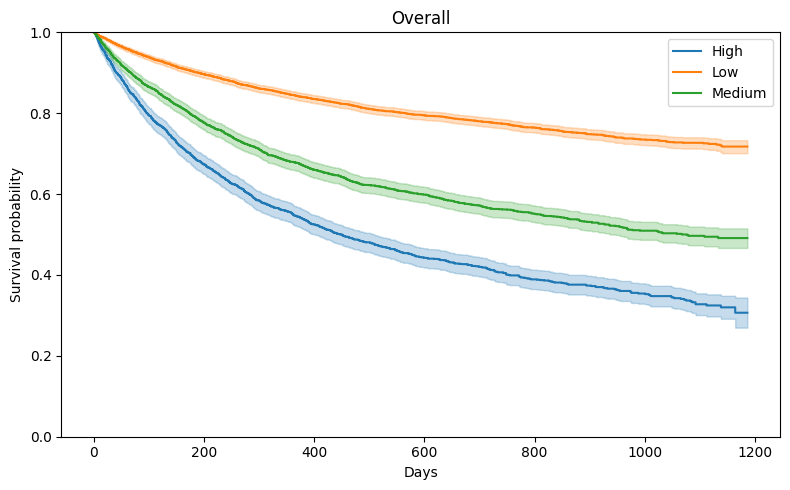

In [38]:
plot_km_by_score(data, "Overall")

Black defendants do recidivate at higher rates according to race specific Kaplan Meier plots.

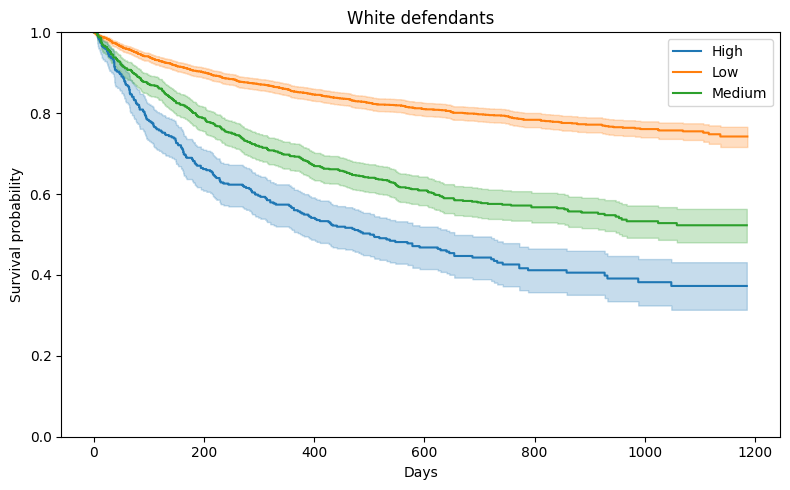

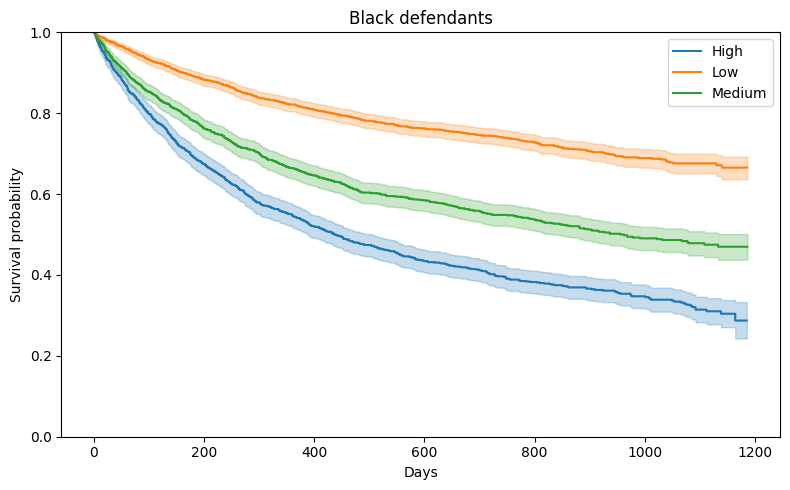

In [39]:
white = data[data["race"] == "Caucasian"].copy()
black = data[data["race"] == "African-American"].copy()

plot_km_by_score(white, "White defendants")
plot_km_by_score(black, "Black defendants")

In [40]:
km_summary_at_time(data, group_col="score_text", time=730)

,group,n,survival_at_730
0,High,2916,0.408147
1,Low,6893,0.775537
2,Medium,3535,0.563147


In [41]:
km_summary_at_time(black, group_col="score_text", time=730)

,group,n,survival_at_730
0,High,2135,0.397613
1,Low,2650,0.743010
2,Medium,2077,0.548462


In [42]:
km_summary_at_time(white, group_col="score_text", time=730)

,group,n,survival_at_730
0,High,598,0.434729
1,Low,2867,0.794607
2,Medium,1099,0.575683


Race specific models have similar concordance values.

In [43]:
white_cph, white_fit_df = fit_cox_model(
    white,
    categorical_refs={"score_factor": "Low"},
)
white_cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
score_factor_Medium,0.841194,2.319133,0.071412,0.701228,0.981159,2.016226,2.667547,0.0,11.779362,4.986922e-32,103.983549
score_factor_High,1.277834,3.588856,0.083627,1.113927,1.441740,3.046299,4.228045,0.0,15.280134,1.037273e-52,172.687466


In [44]:
black_cph, black_fit_df = fit_cox_model(
    black,
    categorical_refs={"score_factor": "Low"},
)
black_cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
score_factor_Medium,0.669960,1.954160,0.056337,0.559541,0.78038,1.749869,2.182301,0.0,11.891924,1.303690e-32,105.919099
score_factor_High,1.094792,2.988561,0.054724,0.987534,1.20205,2.684607,3.326930,0.0,20.005563,4.925963e-89,293.351195


Compas's violent recidivism score has a slightly higher overall concordance score of 65.1%.

In [45]:
violent_data = load_csv(URLS["violent_cox"])
violent_data = violent_data[(violent_data["score_text"] != "N/A") & (violent_data["end"] > violent_data["start"])].copy()

violent_data["race_factor"] = pd.Categorical(violent_data["race"], categories=race_order)
violent_data["score_factor"] = pd.Categorical(violent_data["score_text"], categories=score_order)

violent_cph, violent_fit_df = fit_cox_model(
    violent_data,
    categorical_refs={"score_factor": "Low"},
)
vgrp = violent_data.drop_duplicates("id").copy()
print(len(vgrp))
violent_cph.summary

10999


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
score_factor_Medium,0.806075,2.239101,0.086993,0.635571,0.976578,1.888100,2.655355,0.0,9.265950,1.933487e-20,65.487357
score_factor_High,1.385686,3.997568,0.084095,1.220862,1.550510,3.390109,4.713873,0.0,16.477558,5.319017e-61,200.226454


In this case, there isn't a significant coefficient on African American's with High Scores.

In [46]:
violent_interaction_cph, violent_interaction_fit_df = fit_cox_model(
    violent_data,
    categorical_refs={"race_factor": "Caucasian", "score_factor": "Low"},
    interactions=[("race_factor", "score_factor")],
)
violent_interaction_cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
race_factor_African-American,0.199307,1.220557e+00,0.132056,-0.059518,0.458133,0.942218,1.581119,0.0,1.509259,1.312325e-01,2.929803
race_factor_Asian,-0.580050,5.598706e-01,1.004579,-2.548988,1.388889,0.078161,4.010394,0.0,-0.577406,5.636656e-01,0.827089
race_factor_Hispanic,-0.171562,8.423479e-01,0.214970,-0.592895,0.249770,0.552725,1.283731,0.0,-0.798076,4.248261e-01,1.235056
race_factor_Native American,-12.791767,2.783597e-06,671.662770,-1329.226606,1303.643072,0.000000,inf,0.0,-0.019045,9.848053e-01,0.022090
race_factor_Other,-0.043179,9.577396e-01,0.243259,-0.519958,0.433599,0.594545,1.542801,0.0,-0.177504,8.591127e-01,0.219081
score_factor_Medium,0.633011,1.883273e+00,0.158268,0.322812,0.943210,1.381006,2.568212,0.0,3.999626,6.344265e-05,13.944188
score_factor_High,1.253994,3.504313e+00,0.172004,0.916874,1.591115,2.501458,4.909220,0.0,7.290517,3.087689e-13,41.558538
race_factor_African-American__x__score_factor_Medium,0.128057,1.136617e+00,0.198710,-0.261408,0.517522,0.769966,1.677864,0.0,0.644439,5.192907e-01,0.945386
race_factor_African-American__x__score_factor_High,-0.009283,9.907601e-01,0.206317,-0.413656,0.395091,0.661228,1.484519,0.0,-0.044993,9.641126e-01,0.052726


In [47]:
violent_black = violent_data[violent_data["race"] == "African-American"].copy()
violent_black_cph, violent_black_fit_df = fit_cox_model(
    violent_black,
    categorical_refs={"score_factor": "Low"},
)
violent_black_cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
score_factor_Medium,0.761069,2.140564,0.120178,0.525525,0.996614,1.691346,2.709094,0.0,6.332842,2.406854e-10,31.952133
score_factor_High,1.243325,3.467121,0.113961,1.019966,1.466683,2.773101,4.334834,0.0,10.910136,1.031016e-27,89.647991


In [48]:
violent_white = violent_data[violent_data["race"] == "Caucasian"].copy()
violent_white_cph, violent_white_fit_df = fit_cox_model(
    violent_white,
    categorical_refs={"score_factor": "Low"},
)
violent_white_cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
score_factor_Medium,0.634663,1.886387,0.158276,0.324448,0.944879,1.383267,2.572501,0.0,4.009855,6.075608e-05,14.006612
score_factor_High,1.253841,3.503775,0.172023,0.916681,1.591001,2.500976,4.908659,0.0,7.288778,3.127787e-13,41.539923


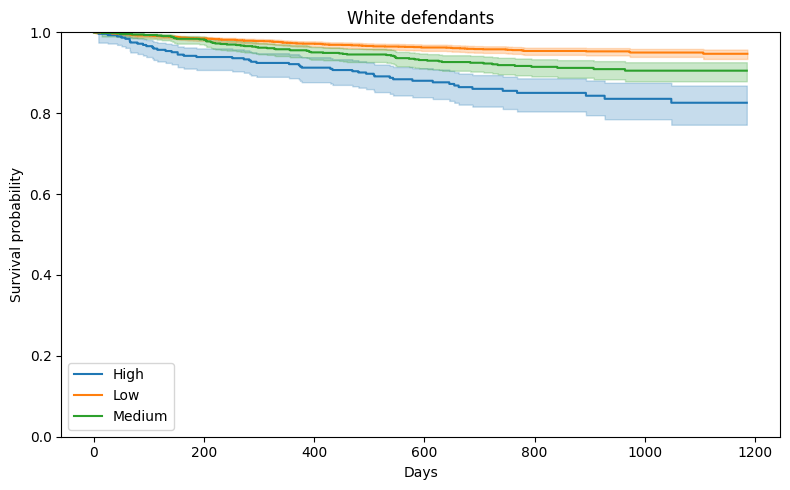

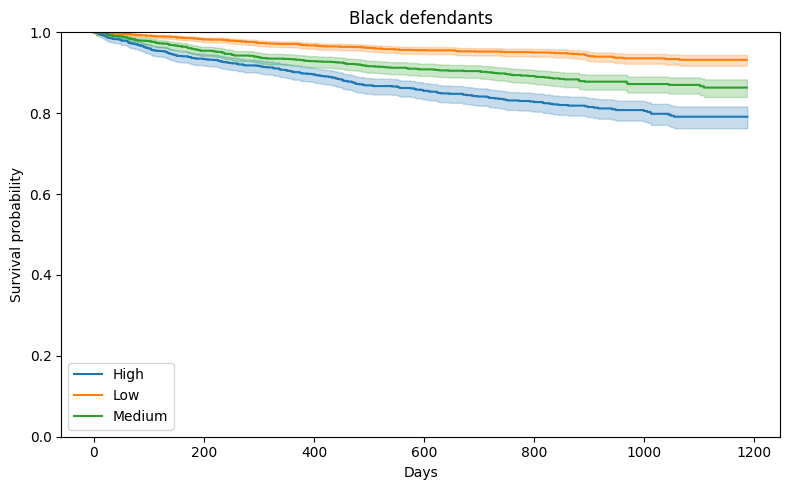

In [49]:
plot_km_by_score(violent_white, "White defendants")
plot_km_by_score(violent_black, "Black defendants")

## Directions of the Racial Bias

The above analysis shows that the Compas algorithm does overpredict African-American defendant's future recidivism, but we haven't yet explored the direction of the bias. We can discover fine differences in overprediction and underprediction by comparing Compas scores across racial lines.

In [50]:
people = []
reader = remote_reader(URLS["cox"])
try:
    while True:
        p = Person(reader)
        if p.valid:
            people.append(p)
except StopIteration:
    pass

pop = list(
    filter(
        lambda i: ((i.recidivist is True and i.lifetime <= 730) or i.lifetime > 730),
        filter(lambda x: x.score_valid, people),
    )
)
recid = list(filter(lambda i: i.recidivist is True and i.lifetime <= 730, pop))
rset = set(recid)
surv = [i for i in pop if i not in rset]

In [51]:
print("All defendants")
table(list(recid), list(surv))

All defendants
 	Low	High
Survived 	2681	1282	0.55
Recidivated	1216	2035	0.45
Total: 7214.00
False positive rate: 32.35
False negative rate: 37.40
Specificity: 0.68
Sensitivity: 0.63
Prevalence: 0.45
PPV: 0.61
NPV: 0.69
LR+: 1.94
LR-: 0.55


In [52]:
print(f"Total pop: {2681 + 1282 + 1216 + 2035}")

Total pop: 7214


In [53]:
import statistics

lifetimes = [i.lifetime for i in pop]
print(f"Average followup time {statistics.mean(lifetimes):.2f} (sd {statistics.stdev(lifetimes):.2f})")
print(f"Median followup time {statistics.median(lifetimes):.0f}")

Average followup time 622.87 (sd 392.19)
Median followup time 766


Overall, the false positive rate is 32.35%.

In [54]:
print("Black defendants")
is_afam = is_race("African-American")
table(list(filter(is_afam, recid)), list(filter(is_afam, surv)))

Black defendants
 	Low	High
Survived 	990	805	0.49
Recidivated	532	1369	0.51
Total: 3696.00
False positive rate: 44.85
False negative rate: 27.99
Specificity: 0.55
Sensitivity: 0.72
Prevalence: 0.51
PPV: 0.63
NPV: 0.65
LR+: 1.61
LR-: 0.51


That number is higher for African Americans at 44.85%.

In [55]:
print("White defendants")
is_white = is_race("Caucasian")
table(list(filter(is_white, recid)), list(filter(is_white, surv)))

White defendants
 	Low	High
Survived 	1139	349	0.61
Recidivated	461	505	0.39
Total: 2454.00
False positive rate: 23.45
False negative rate: 47.72
Specificity: 0.77
Sensitivity: 0.52
Prevalence: 0.39
PPV: 0.59
NPV: 0.71
LR+: 2.23
LR-: 0.62


And lower for whites at 23.45%.

In [56]:
44.85 / 23.45

1.9125799573560769

Which means under COMPAS black defendants are 91% more likely to get a higher score and not go on to commit more crimes than white defendants after two year.

COMPAS scores misclassify white reoffenders as low risk at 70.4% more often than black reoffenders.

In [57]:
47.72 / 27.99

1.7048946052161487

In [58]:
hightable(list(filter(is_white, recid)), list(filter(is_white, surv)))

 	Low	High
Survived 	1407	81	0.61
Recidivated	771	195	0.39
Total: 2454.00
False positive rate: 5.44
False negative rate: 79.81
Specificity: 0.95
Sensitivity: 0.20
Prevalence: 0.39
PPV: 0.71
NPV: 0.65
LR+: 3.71
LR-: 0.84


In [59]:
hightable(list(filter(is_afam, recid)), list(filter(is_afam, surv)))

 	Low	High
Survived 	1511	284	0.49
Recidivated	1160	741	0.51
Total: 3696.00
False positive rate: 15.82
False negative rate: 61.02
Specificity: 0.84
Sensitivity: 0.39
Prevalence: 0.51
PPV: 0.72
NPV: 0.57
LR+: 2.46
LR-: 0.72


## Risk of Violent Recidivism

Compas also offers a score that aims to measure a persons risk of violent recidivism, which has a similar overall accuracy to the Recidivism score.

In [60]:
vpeople = []
reader = remote_reader(URLS["violent_cox"])
try:
    while True:
        p = Person(reader)
        if p.valid:
            vpeople.append(p)
except StopIteration:
    pass

vpop = list(
    filter(
        lambda i: ((i.violent_recidivist is True and i.lifetime <= 730) or i.lifetime > 730),
        filter(lambda x: x.vscore_valid, vpeople),
    )
)
vrecid = list(filter(lambda i: i.violent_recidivist is True and i.lifetime <= 730, vpop))
vrset = set(vrecid)
vsurv = [i for i in vpop if i not in vrset]

In [61]:
print("All defendants")
vtable(list(vrecid), list(vsurv))

All defendants
 	Low	High
Survived 	3822	1484	0.88
Recidivated	347	389	0.12
Total: 6042.00
False positive rate: 27.97
False negative rate: 47.15
Specificity: 0.72
Sensitivity: 0.53
Prevalence: 0.12
PPV: 0.21
NPV: 0.92
LR+: 1.89
LR-: 0.65


Even moreso for Black defendants.

In [62]:
print("Black defendants")
is_afam = is_race("African-American")
vtable(list(filter(is_afam, vrecid)), list(filter(is_afam, vsurv)))

Black defendants
 	Low	High
Survived 	1585	975	0.85
Recidivated	170	273	0.15
Total: 3003.00
False positive rate: 38.09
False negative rate: 38.37
Specificity: 0.62
Sensitivity: 0.62
Prevalence: 0.15
PPV: 0.22
NPV: 0.90
LR+: 1.62
LR-: 0.62


In [63]:
print("White defendants")
is_white = is_race("Caucasian")
vtable(list(filter(is_white, vrecid)), list(filter(is_white, vsurv)))

White defendants
 	Low	High
Survived 	1552	346	0.90
Recidivated	129	77	0.10
Total: 2104.00
False positive rate: 18.23
False negative rate: 62.62
Specificity: 0.82
Sensitivity: 0.37
Prevalence: 0.10
PPV: 0.18
NPV: 0.92
LR+: 2.05
LR-: 0.77


Black defendants are twice as likely to be false positives for a Higher violent score than white defendants.

In [64]:
38.14 / 18.46

2.066088840736728

White defendants are 63% more likely to get a lower score and commit another crime than Black defendants.

In [65]:
62.62 / 38.37

1.63200416992442

## Gender differences in Compas scores

In terms of underlying recidivism rates, we can look at gender specific Kaplan Meier estimates. There is a striking difference between women and men.

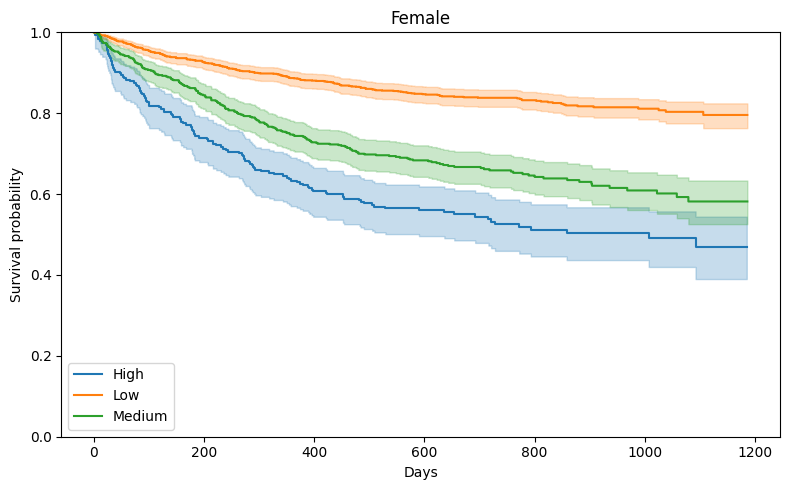

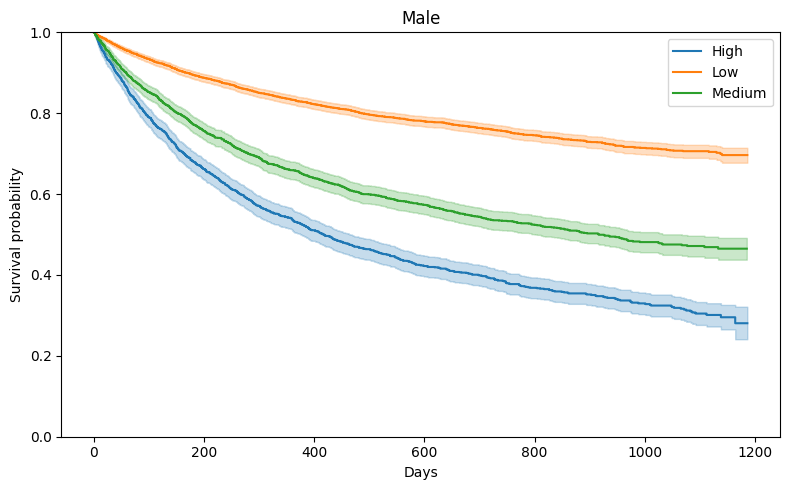

In [66]:
female = data[data["sex"] == "Female"].copy()
male = data[data["sex"] == "Male"].copy()

plot_km_by_score(female, "Female")
plot_km_by_score(male, "Male")

In [67]:
km_summary_at_time(male, group_col="score_text", time=730)

,group,n,survival_at_730
0,High,2488,0.388071
1,Low,5450,0.758033
2,Medium,2778,0.535241


In [68]:
km_summary_at_time(female, group_col="score_text", time=730)

,group,n,survival_at_730
0,High,428,0.525212
1,Low,1443,0.838090
2,Medium,757,0.658641


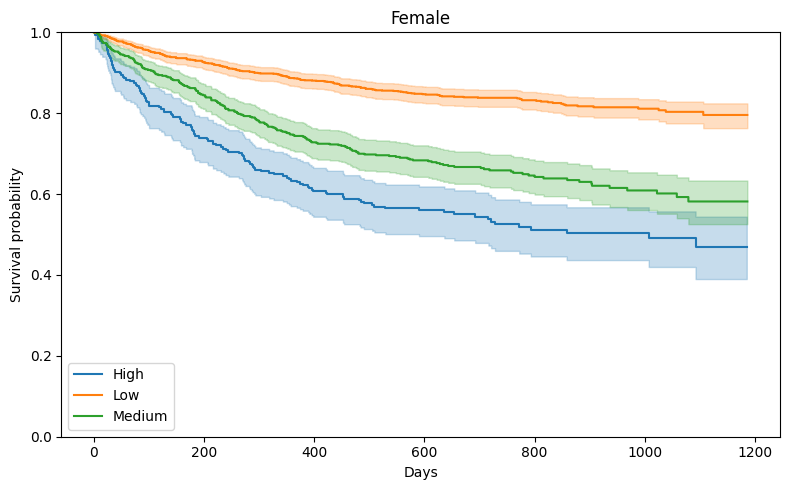

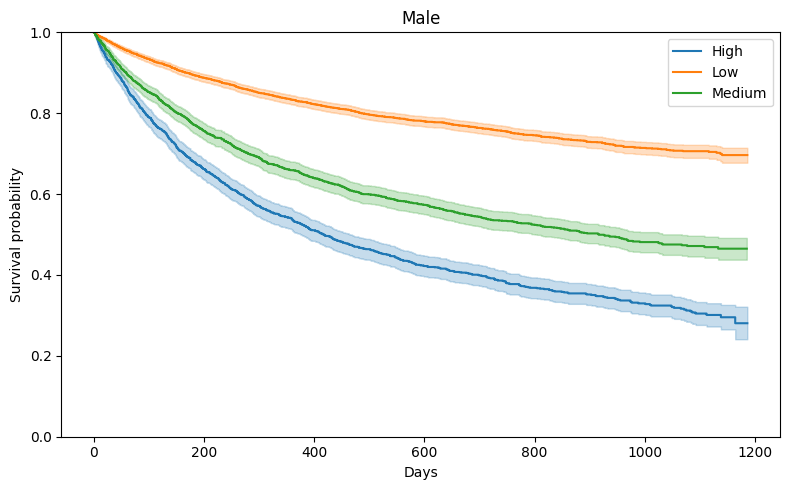

In [69]:
plot_km_by_score(female, "Female")
plot_km_by_score(male, "Male")

As these plots show, the Compas score treats a High risk women the same as a Medium risk man.

# **Individual Assignment 2:**

In [70]:
!pip install shap lime dice-ml -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.2 MB/s eta 0:00:00


In [71]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

from lime.lime_tabular import LimeTabularExplainer
import dice_ml
from dice_ml import Dice

In [72]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

df = raw_data[
    (raw_data["days_b_screening_arrest"] <= 30) &
    (raw_data["days_b_screening_arrest"] >= -30) &
    (raw_data["is_recid"] != -1) &
    (raw_data["c_charge_degree"] != "O") &
    (raw_data["score_text"] != "N/A")
].copy()

print("Shape after filtering:", df.shape)
df.head()

Shape after filtering: (6172, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1


In [73]:
target = "two_year_recid"

features = [
    "age",
    "sex",
    "race",
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "c_charge_degree"
]

df_model = df[features + [target]].copy()

X = df_model[features]
y = df_model[target]

categorical_features = ["sex", "race", "c_charge_degree"]
numeric_features = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4937, 8)
Test shape: (1235, 8)


In [74]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.68582995951417
              precision    recall  f1-score   support

           0       0.68      0.80      0.73       673
           1       0.70      0.55      0.62       562

    accuracy                           0.69      1235
   macro avg       0.69      0.67      0.67      1235
weighted avg       0.69      0.69      0.68      1235



In [75]:
X_train_transformed = model.named_steps["preprocessor"].transform(X_train)
X_test_transformed = model.named_steps["preprocessor"].transform(X_test)

ohe = model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_feature_names)

classifier = model.named_steps["classifier"]

print("Number of transformed features:", len(feature_names))
print(feature_names)

Number of transformed features: 15
['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'sex_Female', 'sex_Male', 'race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other', 'c_charge_degree_F', 'c_charge_degree_M']


**Question 1 - SHAP**

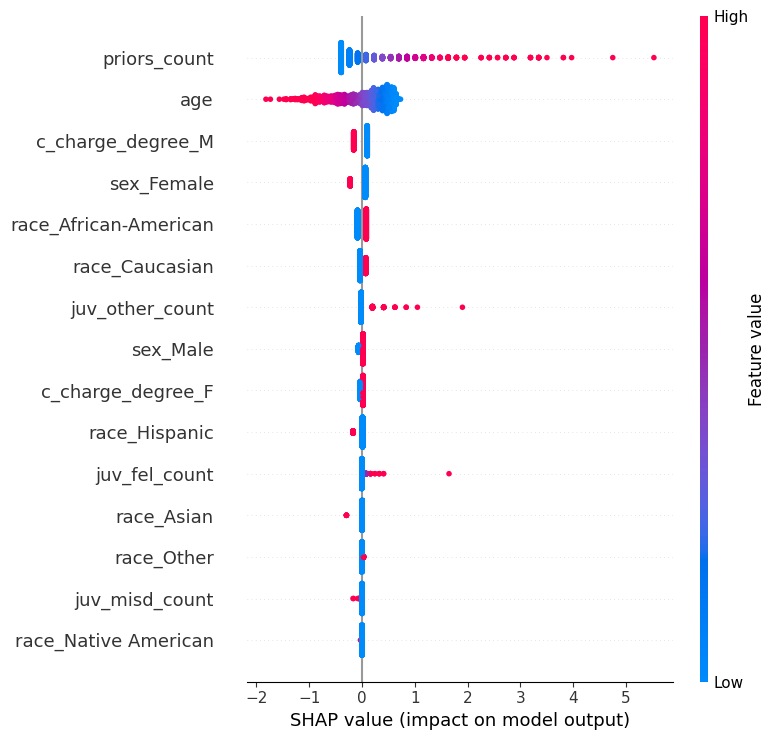

In [76]:
explainer = shap.LinearExplainer(classifier, X_train_transformed, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_transformed)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

In [77]:
test_results = X_test.copy()
test_results["actual"] = y_test.values
test_results["pred_prob"] = y_prob
test_results["pred_label"] = y_pred

groups = ["African-American", "Caucasian"]

selected_indices = {}

for group in groups:
    group_df = test_results[test_results["race"] == group].copy()

    highest_idx = group_df["pred_prob"].idxmax()
    lowest_idx = group_df["pred_prob"].idxmin()

    selected_indices[(group, "highest_risk")] = highest_idx
    selected_indices[(group, "lowest_risk")] = lowest_idx

selected_indices

{('African-American', 'highest_risk'): np.int64(6825),
 ('African-American', 'lowest_risk'): np.int64(4051),
 ('Caucasian', 'highest_risk'): np.int64(6417),
 ('Caucasian', 'lowest_risk'): np.int64(179)}


Waterfall plot for African-American - highest risk
age                              45
sex                            Male
race               African-American
priors_count                     38
juv_fel_count                     0
juv_misd_count                    0
juv_other_count                   0
c_charge_degree                   F
Name: 6825, dtype: object
Predicted probability: 0.9932386119990678


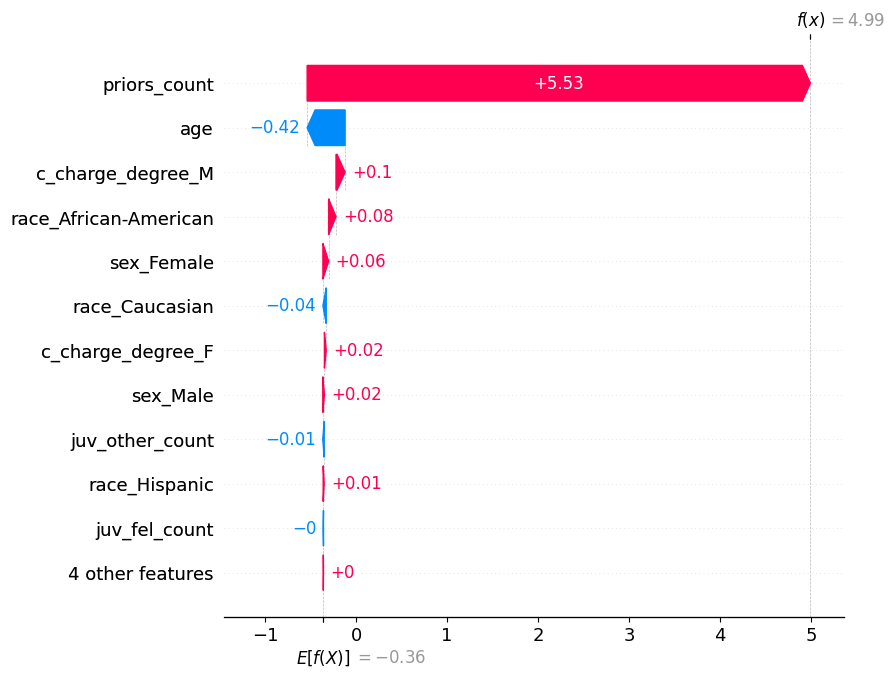


Waterfall plot for African-American - lowest risk
age                              70
sex                            Male
race               African-American
priors_count                      0
juv_fel_count                     0
juv_misd_count                    0
juv_other_count                   0
c_charge_degree                   M
Name: 4051, dtype: object
Predicted probability: 0.09123691954529305


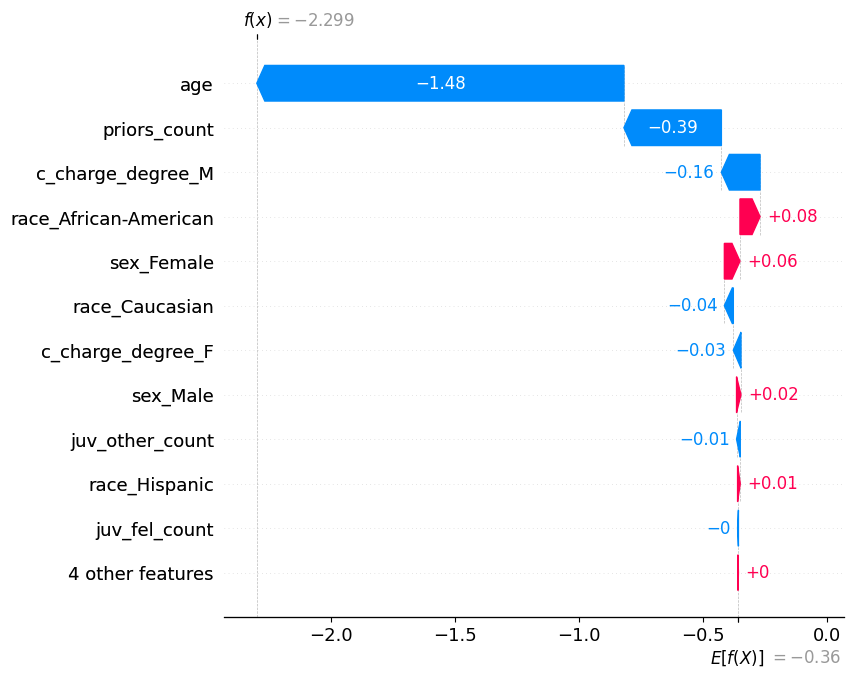


Waterfall plot for Caucasian - highest risk
age                       55
sex                     Male
race               Caucasian
priors_count              27
juv_fel_count              0
juv_misd_count             0
juv_other_count            0
c_charge_degree            M
Name: 6417, dtype: object
Predicted probability: 0.9231663682857029


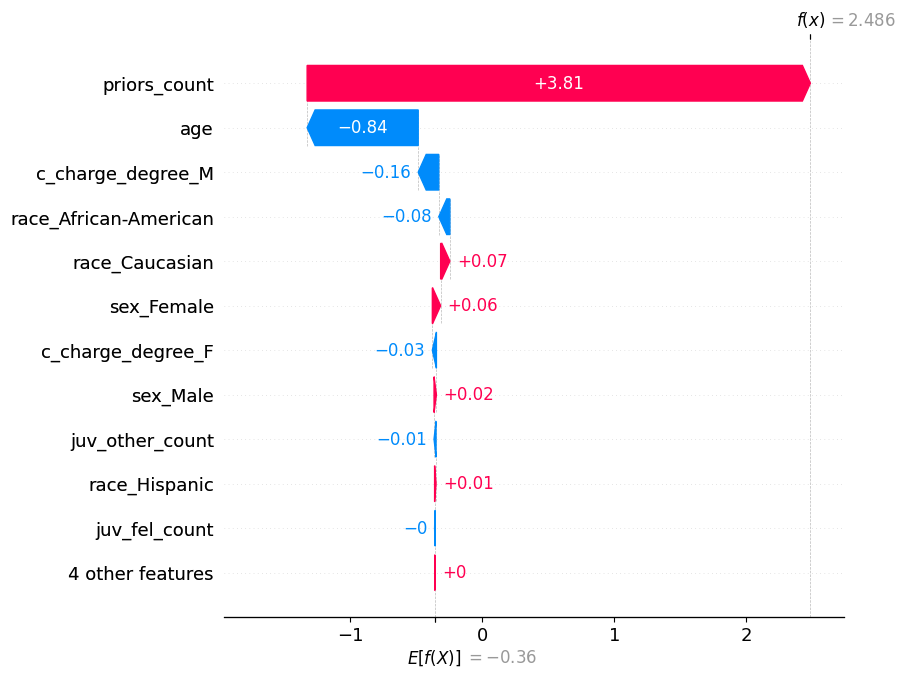


Waterfall plot for Caucasian - lowest risk
age                       78
sex                     Male
race               Caucasian
priors_count               1
juv_fel_count              0
juv_misd_count             0
juv_other_count            0
c_charge_degree            M
Name: 179, dtype: object
Predicted probability: 0.07298353059569782


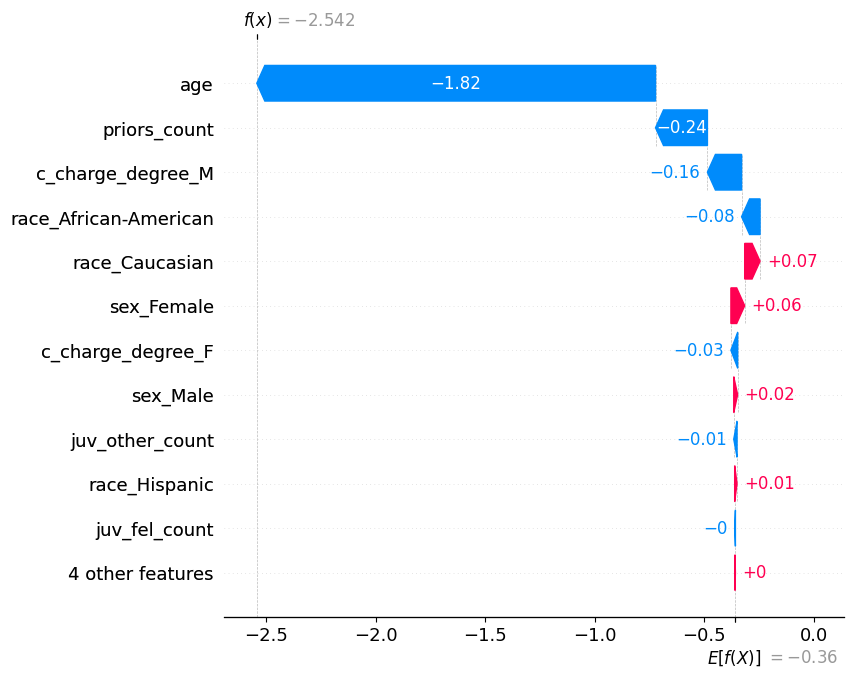

In [78]:
for (group, label), idx in selected_indices.items():
    row_position = X_test.index.get_loc(idx)

    print(f"\nWaterfall plot for {group} - {label.replace('_', ' ')}")
    print(X_test.loc[idx])
    print("Predicted probability:", y_prob[row_position])

    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value,
        shap_values[row_position],
        feature_names=feature_names,
        max_display=12
    )
    plt.show()

**Question 2 - LIME**

In [79]:
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_transformed),
    feature_names=feature_names,
    class_names=["Low Risk", "High Risk"],
    mode="classification"
)


LIME explanation for African-American - highest risk
Predicted probability: 0.9932386119990678


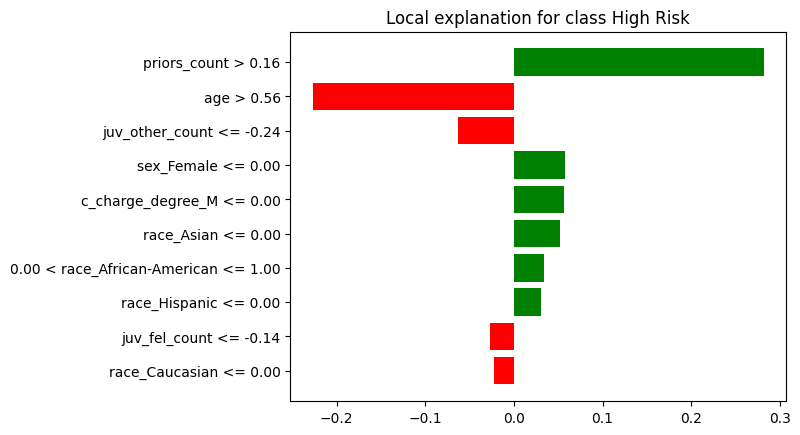


LIME explanation for African-American - lowest risk
Predicted probability: 0.09123691954529305


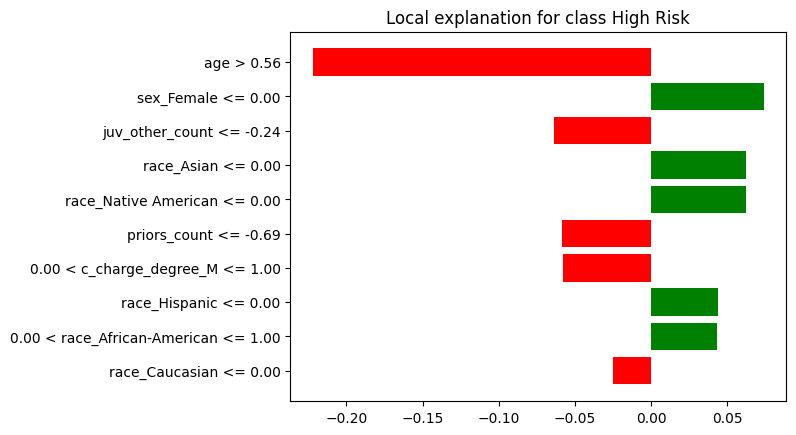


LIME explanation for Caucasian - highest risk
Predicted probability: 0.9231663682857029


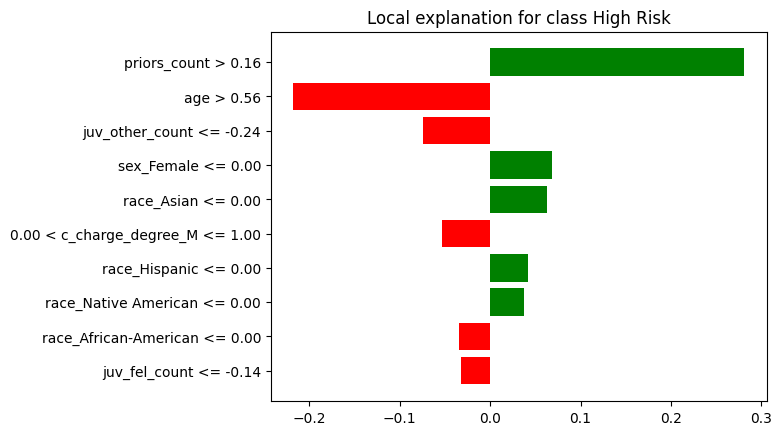


LIME explanation for Caucasian - lowest risk
Predicted probability: 0.07298353059569782


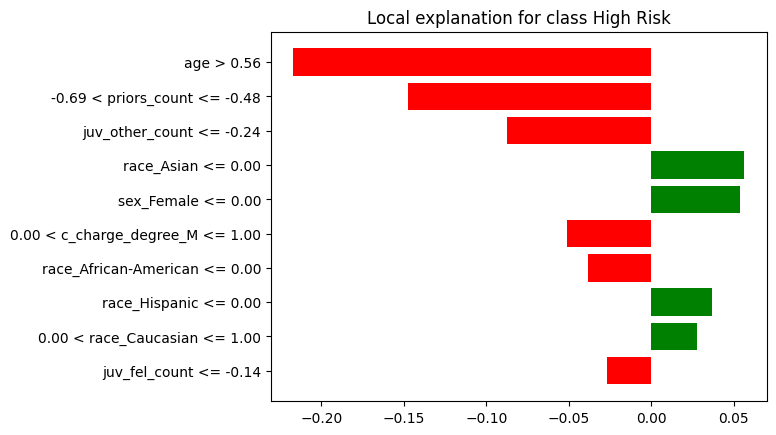

In [80]:
lime_results = {}

for (group, label), idx in selected_indices.items():
    row_position = X_test.index.get_loc(idx)
    instance = np.array(X_test_transformed[row_position]).reshape(-1)

    exp = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=classifier.predict_proba,
        num_features=10
    )

    lime_results[(group, label)] = exp

    print(f"\nLIME explanation for {group} - {label.replace('_', ' ')}")
    print("Predicted probability:", y_prob[row_position])
    fig = exp.as_pyplot_figure()
    plt.show()

In [81]:
for (group, label), idx in selected_indices.items():
    row_position = X_test.index.get_loc(idx)

    shap_contrib = pd.DataFrame({
        "feature": feature_names,
        "shap_value": shap_values[row_position]
    })
    shap_contrib["abs_shap"] = shap_contrib["shap_value"].abs()
    shap_top = shap_contrib.sort_values("abs_shap", ascending=False).head(10)[["feature", "shap_value"]]

    lime_top = pd.DataFrame(lime_results[(group, label)].as_list(), columns=["feature", "lime_weight"])

    print(f"\n{'='*70}")
    print(f"{group} - {label.replace('_', ' ').title()}")
    print(f"{'='*70}")

    print("\nTop SHAP features:")
    print(shap_top.to_string(index=False))

    print("\nTop LIME features:")
    print(lime_top.to_string(index=False))


African-American - Highest Risk

Top SHAP features:
              feature  shap_value
         priors_count    5.527552
                  age   -0.416829
    c_charge_degree_M    0.099645
race_African-American    0.080955
           sex_Female    0.062879
       race_Caucasian   -0.036118
    c_charge_degree_F    0.019680
             sex_Male    0.017771
      juv_other_count   -0.014910
        race_Hispanic    0.010703

Top LIME features:
                             feature  lime_weight
                 priors_count > 0.16     0.281858
                          age > 0.56    -0.226845
            juv_other_count <= -0.24    -0.063654
                  sex_Female <= 0.00     0.057807
           c_charge_degree_M <= 0.00     0.056144
                  race_Asian <= 0.00     0.052306
0.00 < race_African-American <= 1.00     0.033770
               race_Hispanic <= 0.00     0.030812
              juv_fel_count <= -0.14    -0.027475
              race_Caucasian <= 0.00    -0.022129

Af

**Question 3 - Counterfactuals with DiCE**

In [82]:
dice_df = df_model.copy()

continuous_features = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]

dice_data = dice_ml.Data(
    dataframe=dice_df,
    continuous_features=continuous_features,
    outcome_name=target
)

dice_model = dice_ml.Model(model=model, backend="sklearn")

dice_exp = Dice(dice_data, dice_model, method="random")

In [83]:
for (group, label), idx in selected_indices.items():
    query_instance = X_test.loc[[idx]].copy()
    original_pred = model.predict(query_instance)[0]
    original_prob = model.predict_proba(query_instance)[0, 1]

    desired_class = 1 - original_pred  # flip prediction

    print(f"\n{'='*80}")
    print(f"Counterfactuals for {group} - {label.replace('_', ' ')}")
    print(f"{'='*80}")
    print("Original instance:")
    print(query_instance)
    print("Original predicted class:", original_pred)
    print("Original predicted probability:", original_prob)

    try:
        cf = dice_exp.generate_counterfactuals(
            query_instance,
            total_CFs=1,
            desired_class="opposite",
            features_to_vary=["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count", "c_charge_degree"]
        )

        cf_df = cf.cf_examples_list[0].final_cfs_df
        print("\nGenerated counterfactual:")
        print(cf_df)

        immutable_features = ["race", "sex"]
        changed_immutable = []

        if not cf_df.empty:
            for col in immutable_features:
                original_value = query_instance.iloc[0][col]
                cf_value = cf_df.iloc[0][col]
                if original_value != cf_value:
                    changed_immutable.append(col)

        if changed_immutable:
            print("\nWarning: immutable features changed ->", changed_immutable)
        else:
            print("\nNo immutable features changed.")

    except Exception as e:
        print("Counterfactual generation failed:", e)


Counterfactuals for African-American - highest risk
Original instance:
      age   sex              race  priors_count  juv_fel_count  \
6825   45  Male  African-American            38              0   

      juv_misd_count  juv_other_count c_charge_degree  
6825               0                0               F  
Original predicted class: 1
Original predicted probability: 0.9932386119990678


100%|██████████| 1/1 [00:00<00:00,  4.68it/s]



Generated counterfactual:
   age   sex              race  priors_count  juv_fel_count  juv_misd_count  \
0   45  Male  African-American             2              0              12   

   juv_other_count c_charge_degree  two_year_recid  
0                0               F               0  

No immutable features changed.

Counterfactuals for African-American - lowest risk
Original instance:
      age   sex              race  priors_count  juv_fel_count  \
4051   70  Male  African-American             0              0   

      juv_misd_count  juv_other_count c_charge_degree  
4051               0                0               M  
Original predicted class: 0
Original predicted probability: 0.09123691954529305


100%|██████████| 1/1 [00:00<00:00,  6.45it/s]



Generated counterfactual:
   age   sex              race  priors_count  juv_fel_count  juv_misd_count  \
0   70  Male  African-American            16              0               0   

   juv_other_count c_charge_degree  two_year_recid  
0                0               M               1  

No immutable features changed.

Counterfactuals for Caucasian - highest risk
Original instance:
      age   sex       race  priors_count  juv_fel_count  juv_misd_count  \
6417   55  Male  Caucasian            27              0               0   

      juv_other_count c_charge_degree  
6417                0               M  
Original predicted class: 1
Original predicted probability: 0.9231663682857029


100%|██████████| 1/1 [00:00<00:00,  4.96it/s]



Generated counterfactual:
   age   sex       race  priors_count  juv_fel_count  juv_misd_count  \
0   55  Male  Caucasian             2              0               0   

   juv_other_count c_charge_degree  two_year_recid  
0                0               M               0  

No immutable features changed.

Counterfactuals for Caucasian - lowest risk
Original instance:
     age   sex       race  priors_count  juv_fel_count  juv_misd_count  \
179   78  Male  Caucasian             1              0               0   

     juv_other_count c_charge_degree  
179                0               M  
Original predicted class: 0
Original predicted probability: 0.07298353059569782


100%|██████████| 1/1 [00:00<00:00,  5.25it/s]



Generated counterfactual:
   age   sex       race  priors_count  juv_fel_count  juv_misd_count  \
0   78  Male  Caucasian            36             17               0   

   juv_other_count c_charge_degree  two_year_recid  
0                0               M               1  

No immutable features changed.


In [84]:
for (group, label), idx in selected_indices.items():
    query_instance = X_test.loc[[idx]].copy()

    try:
        cf = dice_exp.generate_counterfactuals(
            query_instance,
            total_CFs=1,
            desired_class="opposite",
            features_to_vary=["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count", "c_charge_degree"]
        )
        cf_df = cf.cf_examples_list[0].final_cfs_df

        print(f"\n{'='*70}")
        print(f"{group} - {label.replace('_', ' ').title()}")
        print(f"{'='*70}")

        if cf_df.empty:
            print("No counterfactual found.")
            continue

        original = query_instance.iloc[0]
        cf_row = cf_df.iloc[0]

        changes = []
        for col in query_instance.columns:
            if original[col] != cf_row[col]:
                changes.append((col, original[col], cf_row[col]))

        if changes:
            print("Minimal feature changes to flip prediction:")
            for col, old, new in changes:
                print(f"- {col}: {old} -> {new}")
        else:
            print("No feature changes found.")

    except Exception as e:
        print(f"\n{group} - {label}: failed with error -> {e}")

100%|██████████| 1/1 [00:00<00:00,  4.62it/s]



African-American - Highest Risk
Minimal feature changes to flip prediction:
- priors_count: 38 -> 2


100%|██████████| 1/1 [00:00<00:00,  4.85it/s]



African-American - Lowest Risk
Minimal feature changes to flip prediction:
- priors_count: 0 -> 29
- juv_other_count: 0 -> 1


100%|██████████| 1/1 [00:00<00:00,  2.97it/s]



Caucasian - Highest Risk
Minimal feature changes to flip prediction:
- priors_count: 27 -> 6
- c_charge_degree: M -> F


100%|██████████| 1/1 [00:00<00:00,  4.02it/s]


Caucasian - Lowest Risk
Minimal feature changes to flip prediction:
- age: 78 -> 83
- priors_count: 1 -> 28


# **Individual Assignment 3 start**

**Compute AIR, ME, and SMD for race and sex separately using the
solas-ai Python library. Confirm both produce identical results.**


In [91]:
!pip install solas-ai

import numpy as np
import pandas as pd
import solas_disparity as sd

In [94]:
y_pred = model.predict(X_test)

audit_df = X_test.copy()
audit_df["y_true"] = y_test.values
audit_df["y_pred"] = y_pred

audit_df["favorable"] = (audit_df["y_pred"] == 0).astype(int)

In [95]:
audit_df["African-American"] = (audit_df["race"] == "African-American").astype(int)
audit_df["Caucasian"] = (audit_df["race"] == "Caucasian").astype(int)

audit_df["Female"] = (audit_df["sex"] == "Female").astype(int)
audit_df["Male"] = (audit_df["sex"] == "Male").astype(int)

print(audit_df[["race", "African-American", "Caucasian"]].head())
print(audit_df[["sex", "Female", "Male"]].head())

                  race  African-American  Caucasian
6019          Hispanic                 0          0
2839  African-American                 1          0
2808             Other                 0          0
5770             Asian                 0          0
1885  African-American                 1          0
       sex  Female  Male
6019  Male       0     1
2839  Male       0     1
2808  Male       0     1
5770  Male       0     1
1885  Male       0     1


In [96]:
# Step 3: AIR for race
air_race = sd.adverse_impact_ratio(
    group_data=audit_df,
    protected_groups=["African-American"],
    reference_groups=["Caucasian"],
    group_categories=["race"],
    outcome=audit_df["favorable"],
    sample_weight=None,
    air_threshold=0.80,
    percent_difference_threshold=0.0
)

print("AIR - Race")
print(air_race)

AIR - Race
+------------------------------+-------------------+
|       Protected Groups       | African-American  |
|       Reference Groups       |     Caucasian     |
|       Group Categories       |       race        |
|        AIR Threshold         |        0.8        |
| Percent Difference Threshold |        0.0        |
|       Shortfall Method       | to_reference_mean |
|       Affected Groups        | African-American  |
|      Affected Reference      |     Caucasian     |
|     Affected Categories      |       race        |
+------------------------------+-------------------+


In [97]:
# Step 4: AIR for sex
air_sex = sd.adverse_impact_ratio(
    group_data=audit_df,
    protected_groups=["Female"],
    reference_groups=["Male"],
    group_categories=["sex"],
    outcome=audit_df["favorable"],
    sample_weight=None,
    air_threshold=0.80,
    percent_difference_threshold=0.0
)

print("AIR - Sex")
print(air_sex)

AIR - Sex
+------------------------------+-------------------+
|       Protected Groups       |      Female       |
|       Reference Groups       |       Male        |
|       Group Categories       |        sex        |
|        AIR Threshold         |        0.8        |
| Percent Difference Threshold |        0.0        |
|       Shortfall Method       | to_reference_mean |
|       Affected Groups        |                   |
|      Affected Reference      |                   |
|     Affected Categories      |                   |
+------------------------------+-------------------+


In [98]:
# Step 5: ME manually
race_protected_rate = audit_df.loc[audit_df["race"] == "African-American", "favorable"].mean()
race_reference_rate = audit_df.loc[audit_df["race"] == "Caucasian", "favorable"].mean()
me_race = race_protected_rate - race_reference_rate

sex_protected_rate = audit_df.loc[audit_df["sex"] == "Female", "favorable"].mean()
sex_reference_rate = audit_df.loc[audit_df["sex"] == "Male", "favorable"].mean()
me_sex = sex_protected_rate - sex_reference_rate

print("ME - Race:", me_race)
print("ME - Sex:", me_sex)

ME - Race: -0.30560782150255567
ME - Sex: 0.2969939948429322


In [99]:
# Step 6: SMD manually
def smd(p_protected, p_reference):
    pooled = np.sqrt((p_protected * (1 - p_protected) + p_reference * (1 - p_reference)) / 2)
    if pooled == 0:
        return 0
    return (p_protected - p_reference) / pooled

smd_race = smd(race_protected_rate, race_reference_rate)
smd_sex = smd(sex_protected_rate, sex_reference_rate)

print("SMD - Race:", smd_race)
print("SMD - Sex:", smd_sex)

SMD - Race: -0.6700256013126643
SMD - Sex: 0.7111013905123879


In [100]:
# Step 7: final summary table
summary = pd.DataFrame({
    "Attribute": ["Race", "Sex"],
    "Protected Group": ["African-American", "Female"],
    "Reference Group": ["Caucasian", "Male"],
    "Protected Rate": [race_protected_rate, sex_protected_rate],
    "Reference Rate": [race_reference_rate, sex_reference_rate],
    "ME": [me_race, me_sex],
    "SMD": [smd_race, smd_sex]
})

print(summary)

  Attribute   Protected Group Reference Group  Protected Rate  Reference Rate  \
0      Race  African-American       Caucasian        0.483619        0.789227   
1       Sex            Female            Male        0.879828        0.582834   

         ME       SMD  
0 -0.305608 -0.670026  
1  0.296994  0.711101  


**Build an intersectional analysis (race × sex). Report the worst-group
AIR and interpret it.**

In [101]:
audit_df["race_sex"] = audit_df["race"] + " | " + audit_df["sex"]

print(audit_df["race_sex"].value_counts())

race_sex
African-American | Male      525
Caucasian | Male             341
African-American | Female    116
Caucasian | Female            86
Hispanic | Male               76
Other | Male                  52
Hispanic | Female             18
Other | Female                13
Asian | Male                   7
Native American | Male         1
Name: count, dtype: int64


In [102]:
group_rates = audit_df.groupby("race_sex")["favorable"].mean().reset_index()
group_rates = group_rates.rename(columns={"favorable": "favorable_rate"})

print(group_rates)

                    race_sex  favorable_rate
0  African-American | Female        0.793103
1    African-American | Male        0.415238
2               Asian | Male        1.000000
3         Caucasian | Female        0.953488
4           Caucasian | Male        0.747801
5          Hispanic | Female        1.000000
6            Hispanic | Male        0.736842
7     Native American | Male        1.000000
8             Other | Female        1.000000
9               Other | Male        0.903846


In [103]:
reference_group = "Caucasian | Male"

In [104]:
ref_rate = group_rates.loc[
    group_rates["race_sex"] == reference_group, "favorable_rate"
].values[0]

In [105]:
group_rates["AIR"] = group_rates["favorable_rate"] / ref_rate

print(group_rates.sort_values("AIR"))

                    race_sex  favorable_rate       AIR
1    African-American | Male        0.415238  0.555279
6            Hispanic | Male        0.736842  0.985346
4           Caucasian | Male        0.747801  1.000000
0  African-American | Female        0.793103  1.060581
9               Other | Male        0.903846  1.208673
3         Caucasian | Female        0.953488  1.275057
5          Hispanic | Female        1.000000  1.337255
2               Asian | Male        1.000000  1.337255
7     Native American | Male        1.000000  1.337255
8             Other | Female        1.000000  1.337255


In [106]:
worst_group = group_rates.loc[group_rates["AIR"].idxmin()]

print("\nWorst Group:")
print(worst_group)


Worst Group:
race_sex          African-American | Male
favorable_rate                   0.415238
AIR                              0.555279
Name: 1, dtype: object


An intersectional analysis was performed by combining race and sex into a single attribute. The favorable outcome rate was computed for each group and compared to the reference group (Caucasian Male).

The lowest AIR was observed for African-American Male, indicating that this group receives the lowest rate of favorable outcomes relative to the reference group.

Since the AIR for this group is significantly below 0.8, it suggests a strong disparity and potential bias against African-American males. This highlights that fairness issues are more pronounced when considering intersectional groups rather than individual attributes alone.

**Compute FPR and FNR disparities by race. Test statistical
significance with a two-proportion z-test.**

In [107]:
audit_df["TP"] = ((audit_df["y_true"] == 1) & (audit_df["y_pred"] == 1)).astype(int)
audit_df["TN"] = ((audit_df["y_true"] == 0) & (audit_df["y_pred"] == 0)).astype(int)
audit_df["FP"] = ((audit_df["y_true"] == 0) & (audit_df["y_pred"] == 1)).astype(int)
audit_df["FN"] = ((audit_df["y_true"] == 1) & (audit_df["y_pred"] == 0)).astype(int)

In [108]:
race_metrics = audit_df.groupby("race").agg({
    "FP": "sum",
    "TN": "sum",
    "FN": "sum",
    "TP": "sum"
}).reset_index()

race_metrics["FPR"] = race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])

race_metrics["FNR"] = race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])

print(race_metrics[["race", "FPR", "FNR"]])

               race       FPR       FNR
0  African-American  0.312500  0.299703
1             Asian  0.000000  1.000000
2         Caucasian  0.135338  0.664596
3          Hispanic  0.081633  0.644444
4   Native American  0.000000       NaN
5             Other  0.021277  0.777778


In [109]:
aa = race_metrics[race_metrics["race"] == "African-American"].iloc[0]

ca = race_metrics[race_metrics["race"] == "Caucasian"].iloc[0]

In [110]:
from statsmodels.stats.proportion import proportions_ztest

In [111]:
count_fpr = [aa["FP"], ca["FP"]]
nobs_fpr = [aa["FP"] + aa["TN"], ca["FP"] + ca["TN"]]

z_fpr, p_fpr = proportions_ztest(count_fpr, nobs_fpr)

print("FPR Z-test:")
print("z-stat:", z_fpr)
print("p-value:", p_fpr)

FPR Z-test:
z-stat: 5.0155302787409815
p-value: 5.288739441925726e-07


**Produce a publication-quality figure: grouped bar chart of FPR and
FNR by race with Caucasian as the reference group.**

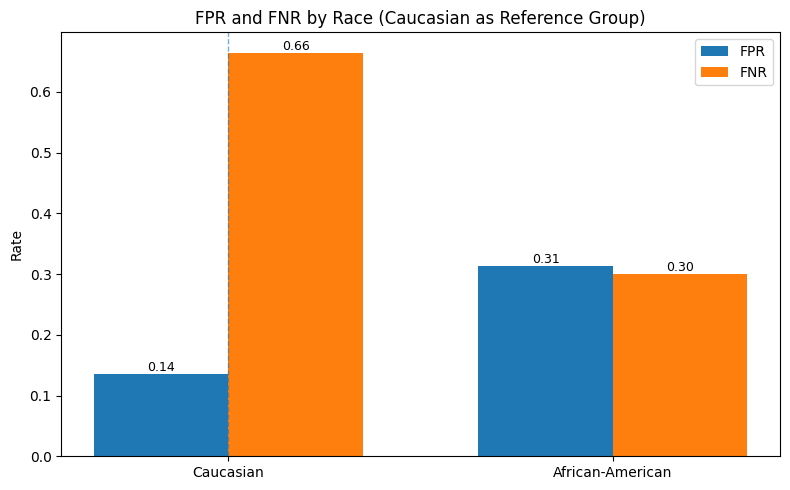

In [112]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = race_metrics[race_metrics["race"].isin(["African-American", "Caucasian"])].copy()

plot_df = plot_df.set_index("race").loc[["Caucasian", "African-American"]].reset_index()

labels = plot_df["race"]
fpr = plot_df["FPR"]
fnr = plot_df["FNR"]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width/2, fpr, width, label='FPR')
bars2 = plt.bar(x + width/2, fnr, width, label='FNR')

plt.ylabel("Rate")
plt.title("FPR and FNR by Race (Caucasian as Reference Group)")
plt.xticks(x, labels)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.axvline(x=0, linestyle='--', linewidth=1, alpha=0.6)

plt.tight_layout()
plt.show()

**To**: Regulatory Review Office

**Subject**: Compliance Memo – Disparate Impact Audit of Recidivism Model

This memo summarizes the findings from a fairness audit conducted on a recidivism prediction model using the COMPAS dataset. The analysis focused on evaluating potential disparities across race and sex using multiple fairness metrics, including Adverse Impact Ratio (AIR), Mean Error (ME), Standardized Mean Difference (SMD), as well as False Positive Rate (FPR) and False Negative Rate (FNR).

The results indicate notable disparities across racial groups. The AIR for African-American individuals falls below the commonly used 0.8 threshold, suggesting a potential adverse impact when compared to Caucasian individuals. This is further supported by negative ME values and relatively large SMD values, both indicating that African-American individuals receive fewer favorable outcomes on average. In contrast, disparities by sex are present but less pronounced, with values closer to fairness thresholds.

An intersectional analysis combining race and sex revealed that African-American males experience the lowest rate of favorable outcomes, making them the most adversely affected group. This highlights that disparities become more pronounced when considering overlapping demographic attributes rather than evaluating each attribute independently.

Error-based analysis shows that African-American individuals have a higher False Positive Rate, meaning they are more likely to be incorrectly classified as high risk. Meanwhile, Caucasian individuals exhibit a higher False Negative Rate, indicating a greater likelihood of being incorrectly classified as low risk. This difference suggests an imbalance in how prediction errors are distributed across groups, which may have real-world implications. Two-proportion z-tests confirm that these differences are statistically significant, suggesting that the observed disparities are unlikely to be due to random variation.

There are some limitations to this analysis. The results depend on the specific model, preprocessing steps, and threshold used for classification. Additionally, fairness metrics capture statistical patterns but do not fully account for broader social or contextual factors that may influence outcomes. The dataset itself may also contain historical biases, which can be reflected in the model’s predictions.

Overall, the findings suggest that the model exhibits measurable disparities, particularly across racial groups, and may require further review or mitigation before deployment.
